In [1]:
import os

print(os.listdir('/content'))

['.config', 'Advertising.csv', 'sample_data']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/Advertising.csv')

In [4]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.shape

(200, 5)

In [6]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [8]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [11]:
predictions = model.predict(X_test)

In [12]:
print(predictions[:10])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [13]:
#measure model accurancy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 1.4607567168117603
MSE: 3.1740973539761033
R2 Score: 0.899438024100912


In [14]:
#predict sales for new advertising values
new_data = pd.DataFrame({
    'TV': [250],
    'Radio': [40],
    'Newspaper': [50]
})

predicted_sales = model.predict(new_data)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 21.86730459174513


In [16]:
#remove the extra column
df = df.drop("Unnamed: 0", axis=1)

In [17]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [18]:
#understand dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [19]:
#statistical summary
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [20]:
#check missing values
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [21]:
#check duplicate vlaues
df.duplicated().sum()

np.int64(0)

In [22]:
#correlation between variables
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


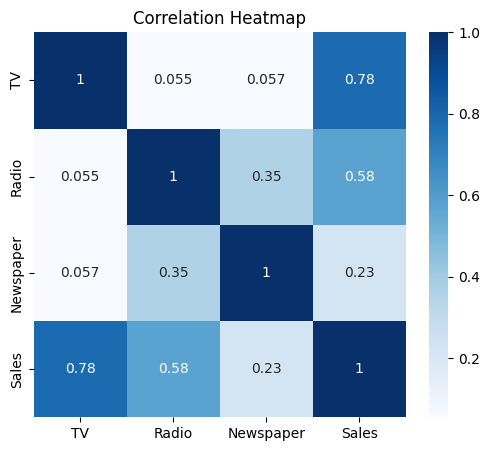

In [23]:
#draw the heatmap
plt.figure(figsize=(6,5))

sns.heatmap(df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

In [24]:
#sepreate input x and output y
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [27]:
#split the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
#check the sizes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


In [29]:
#import the model
from sklearn.linear_model import LinearRegression

In [30]:
#create the model
model = LinearRegression()

In [35]:
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [51]:
#train the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [52]:
#create future advertaising budgets
future_data = pd.DataFrame({
    'TV': [50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325],
    'Radio': [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65],
    'Newspaper': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
})

In [53]:
#predict future sales
future_predictions = model.predict(future_data)

In [54]:
#add predictions to the table
future_data['Predicted Sales'] = future_predictions

future_data

,TV,Radio,Newspaper,Predicted Sales
0,50,10,5,7.121299
1,75,15,10,9.199318
2,100,20,15,11.277337
3,125,25,20,13.355356
4,150,30,25,15.433374
5,175,35,30,17.511393
6,200,40,35,19.589412
7,225,45,40,21.667431
8,250,50,45,23.745450
9,275,55,50,25.823468


In [55]:
#create a month column
future_data['Month'] = [
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec'
]

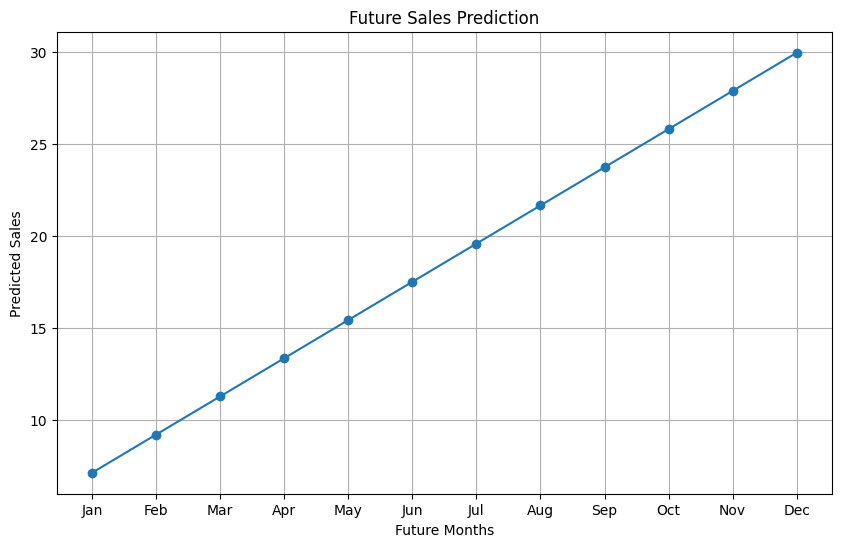

In [56]:
#plot the future prediction graph
plt.figure(figsize=(10,6))

plt.plot(
    future_data['Month'],
    future_data['Predicted Sales'],
    marker='o'
)

plt.title('Future Sales Prediction')
plt.xlabel('Future Months')
plt.ylabel('Predicted Sales')

plt.grid(True)

plt.show()

In [57]:
#display th eprediction table
print(future_data)

     TV  Radio  Newspaper  Predicted Sales Month
0    50     10          5         7.121299   Jan
1    75     15         10         9.199318   Feb
2   100     20         15        11.277337   Mar
3   125     25         20        13.355356   Apr
4   150     30         25        15.433374   May
5   175     35         30        17.511393   Jun
6   200     40         35        19.589412   Jul
7   225     45         40        21.667431   Aug
8   250     50         45        23.745450   Sep
9   275     55         50        25.823468   Oct
10  300     60         55        27.901487   Nov
11  325     65         60        29.979506   Dec


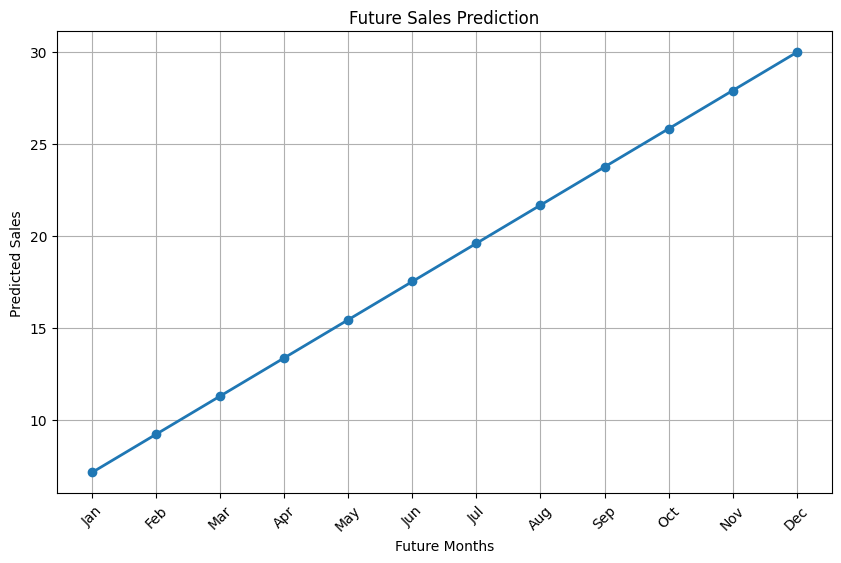

In [58]:
plt.figure(figsize=(10,6))

plt.plot(
    future_data['Month'],
    future_data['Predicted Sales'],
    marker='o',
    linewidth=2
)

plt.title("Future Sales Prediction")
plt.xlabel("Future Months")
plt.ylabel("Predicted Sales")

plt.grid(True)
plt.xticks(rotation=45)

plt.show()

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Correlation Heatmap
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

# -----------------------------
# 2. TV vs Sales
# -----------------------------
plt.figure(figsize=(6,5))
sns.regplot(data=df, x="TV", y="Sales")
plt.title("TV Advertising vs Sales")
plt.savefig("tv_vs_sales.png", dpi=300, bbox_inches="tight")
plt.close()

# -----------------------------
# 3. Radio vs Sales
# -----------------------------
plt.figure(figsize=(6,5))
sns.regplot(data=df, x="Radio", y="Sales")
plt.title("Radio Advertising vs Sales")
plt.savefig("radio_vs_sales.png", dpi=300, bbox_inches="tight")
plt.close()

# -----------------------------
# 4. Newspaper vs Sales
# -----------------------------
plt.figure(figsize=(6,5))
sns.regplot(data=df, x="Newspaper", y="Sales")
plt.title("Newspaper Advertising vs Sales")
plt.savefig("newspaper_vs_sales.png", dpi=300, bbox_inches="tight")
plt.close()

# -----------------------------
# 5. Actual vs Predicted Sales
# -----------------------------
plt.figure(figsize=(7,6))
plt.scatter(y_test, predictions)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.close()

# -----------------------------
# 6. Future Sales Prediction
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(
    future_data["Month"],
    future_data["Predicted Sales"],
    marker="o",
    linewidth=2
)
plt.title("Future Sales Prediction")
plt.xlabel("Future Months")
plt.ylabel("Predicted Sales")
plt.grid(True)
plt.xticks(rotation=45)
plt.savefig("future_prediction.png", dpi=300, bbox_inches="tight")
plt.close()

print("✅ All graphs have been saved successfully!")

✅ All graphs have been saved successfully!


In [60]:
import os

for file in os.listdir('/content'):
    if file.endswith('.png'):
        print(file)

heatmap.png
tv_vs_sales.png
radio_vs_sales.png
future_prediction.png
newspaper_vs_sales.png
actual_vs_predicted.png
